<a href="https://colab.research.google.com/github/dbazan96/preentrega.visualizaciones/blob/main/Copia_de_Visualizaciones%2BBazan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Instalación de libererías y carga de datos
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns

#Enlaces de base de datos en objetos
url1 = 'https://raw.githubusercontent.com/dbazan96/preentrega.visualizaciones/refs/heads/main/new_test.csv'
url2 = 'https://raw.githubusercontent.com/dbazan96/preentrega.visualizaciones/refs/heads/main/new_train.csv'

#Lectura del dataset considerando el separador ',' al ser un documento csv.
Test = pd.read_csv(url1, sep=',')
Train = pd.read_csv(url2, sep=',')


#Observación de data
Test.head()

Train.head()


Train.info()

#-- Análisis Exploratorio de datos --

#Identificando valores
Train.isnull().sum()

Train.drop("default",axis=1,inplace=True)
Test.drop("default",axis=1,inplace=True)

Train.dtypes

duplicate_rows = Train[Train.duplicated()]
if duplicate_rows.empty:
    print("No duplicate rows found.")
else:
    Train=Train.drop_duplicates()

Train.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32950 entries, 0 to 32949
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          32950 non-null  int64 
 1   job          32950 non-null  object
 2   marital      32950 non-null  object
 3   education    32950 non-null  object
 4   default      32950 non-null  object
 5   housing      32950 non-null  object
 6   loan         32950 non-null  object
 7   contact      32950 non-null  object
 8   month        32950 non-null  object
 9   day_of_week  32950 non-null  object
 10  duration     32950 non-null  int64 
 11  campaign     32950 non-null  int64 
 12  pdays        32950 non-null  int64 
 13  previous     32950 non-null  int64 
 14  poutcome     32950 non-null  object
 15  y            32950 non-null  object
dtypes: int64(5), object(11)
memory usage: 4.0+ MB


,age,duration,campaign,pdays,previous
count,32941.000000,32941.000000,32941.000000,32941.000000,32941.000000
mean,40.013023,258.165660,2.560851,962.042318,0.174767
std,10.403121,258.996865,2.752607,187.975778,0.499084
min,17.000000,0.000000,1.000000,0.000000,0.000000
25%,32.000000,103.000000,1.000000,999.000000,0.000000
50%,38.000000,180.000000,2.000000,999.000000,0.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000
max,98.000000,4918.000000,56.000000,999.000000,7.000000


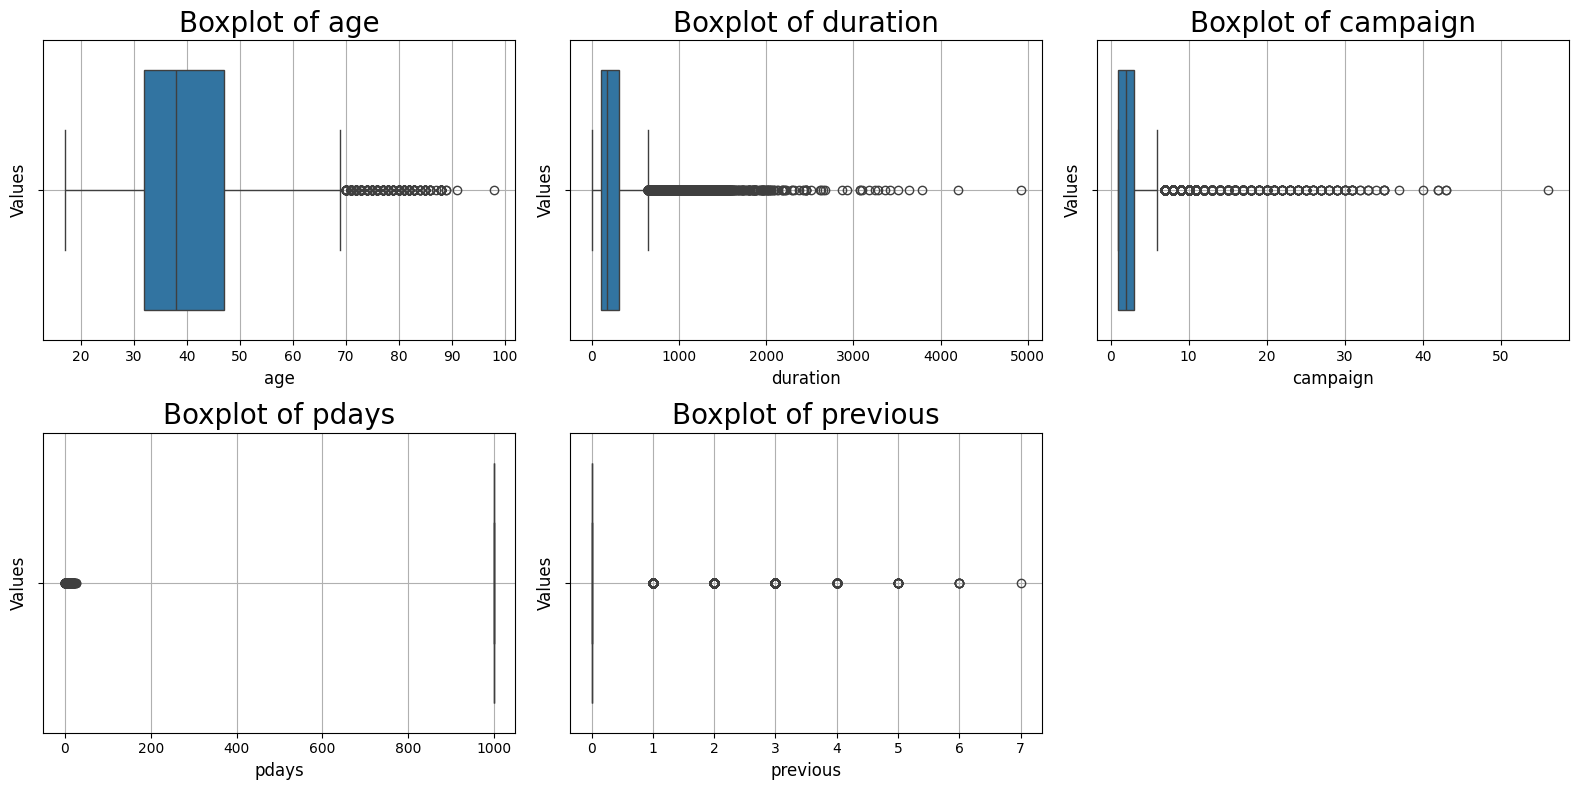

In [ ]:
#Se utiliza los boxplots para ver que variables enteras presentan outliers que pueden afectar al análisis de datos y modelo de predicción. En el gráfico se observa que las columnas de datos de 'age',
#'duration' y 'campaign' tiene la mayor concentración de outliers que superan el limite superior del rango promedio de valores contenidos en las

Num_dtypes = Train.select_dtypes(include=["int64"])
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 8))

axes = axes.flatten()

for i, col in enumerate(Num_dtypes):
    sns.boxplot(x=col, data=Train, ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}", fontsize=20)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel("Values", fontsize=12)
    axes[i].tick_params(axis='both', labelsize=10)
    axes[i].grid(True)

plt.tight_layout()
axes[-1].axis("off")

# Proyección de plots
plt.show()


In [ ]:
columns = ['age', 'duration', 'campaign', 'pdays', 'previous']

for col in columns:
  percentile25 = Train[col].quantile(0.25)
  percentile75 = Train[col].quantile(0.75)
  IQR = percentile75 - percentile25
  print("Column:",col)
  print("The Interquartile Range (IQR):", IQR)

#Encontrando Outliers
  lower_limit  = percentile25 - (1.5 * IQR)
  upper_limit = percentile75 + (1.5 * IQR)
  print("Upper Limit:", upper_limit)
  print("Lower Limit:", lower_limit)

#Cantidad de outliers que exceden el limite superior
  upper_limit_len = Train[(Train[col] > upper_limit)]
  print('The outliers above the upper limit are:', len(upper_limit_len))
#Cantidad de outliers totales
  Outliers_len = Train[(Train[col] > upper_limit) | (Train[col] < lower_limit)]
  print('The outliers in',col, 'column are', len(Outliers_len))
#Enlistar la posición de outliers según su fila para luego eliminarlos
  Outlier_Indexes = list(upper_limit_len.index)
  print('--------------------------------------------------------------------')

#Eliminando outliers
print('\nNumber of Rows in Train dataset: ',len(Train))
Train= Train.drop(Outlier_Indexes)
print('After droping outliers, Number of Rows in Train dataset: ',len(Train))

Column: age
The Interquartile Range (IQR): 15.0
Upper Limit: 69.5
Lower Limit: 9.5
The outliers above the upper limit are: 367
The outliers in age column are 367
--------------------------------------------------------------------
Column: duration
The Interquartile Range (IQR): 216.0
Upper Limit: 643.0
Lower Limit: -221.0
The outliers above the upper limit are: 2366
The outliers in duration column are 2366
--------------------------------------------------------------------
Column: campaign
The Interquartile Range (IQR): 2.0
Upper Limit: 6.0
Lower Limit: -2.0
The outliers above the upper limit are: 1916
The outliers in campaign column are 1916
--------------------------------------------------------------------
Column: pdays
The Interquartile Range (IQR): 0.0
Upper Limit: 999.0
Lower Limit: 999.0
The outliers above the upper limit are: 0
The outliers in pdays column are 1226
--------------------------------------------------------------------
Column: previous
The Interquartile Range (I

<ipython-input-3-8e4816de8c16>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'age', y = 'job', data = Train, palette='bright')


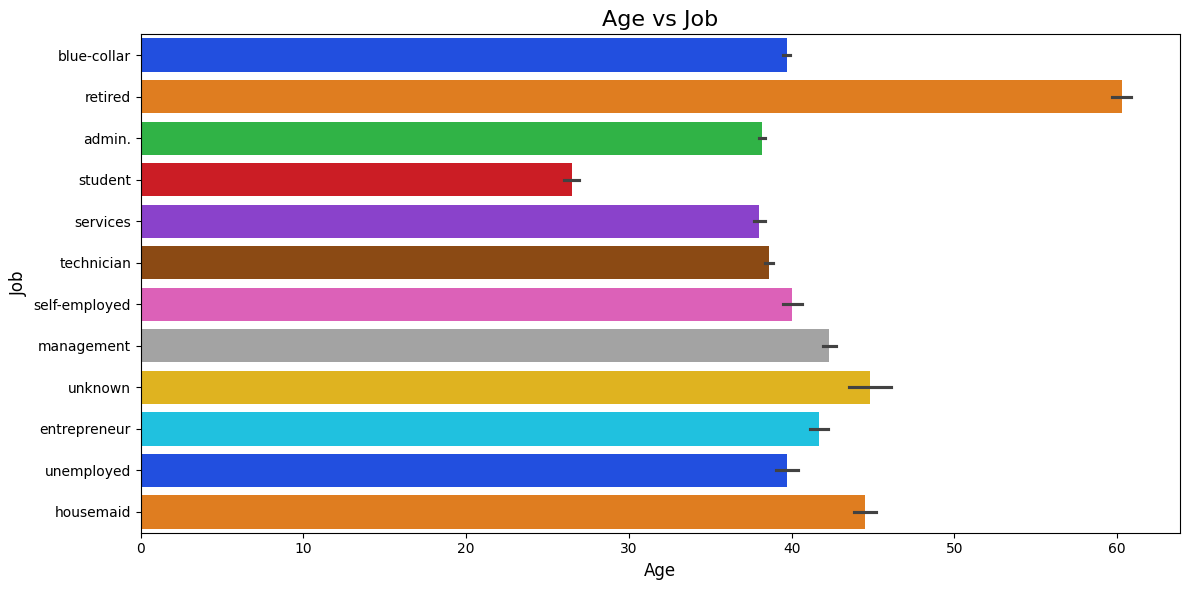

In [ ]:
#Graphic Age vs Jobs

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.barplot(x = 'age', y = 'job', data = Train, palette='bright')
plt.title('Age vs Job', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Job', fontsize=12)
plt.tight_layout()
plt.show()

<ipython-input-7-a807268b5956>:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(Train[column], kde=True, bins=10, palette="bright")
<ipython-input-7-a807268b5956>:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(Train[column], kde=True, bins=10, palette="bright")
<ipython-input-7-a807268b5956>:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(Train[column], kde=True, bins=10, palette="bright")
<ipython-input-7-a807268b5956>:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(Train[column], kde=True, bins=10, palette="bright")
<ipython-input-7-a807268b5956>:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(Train[column], kde=True, bins=10, palette="bright")


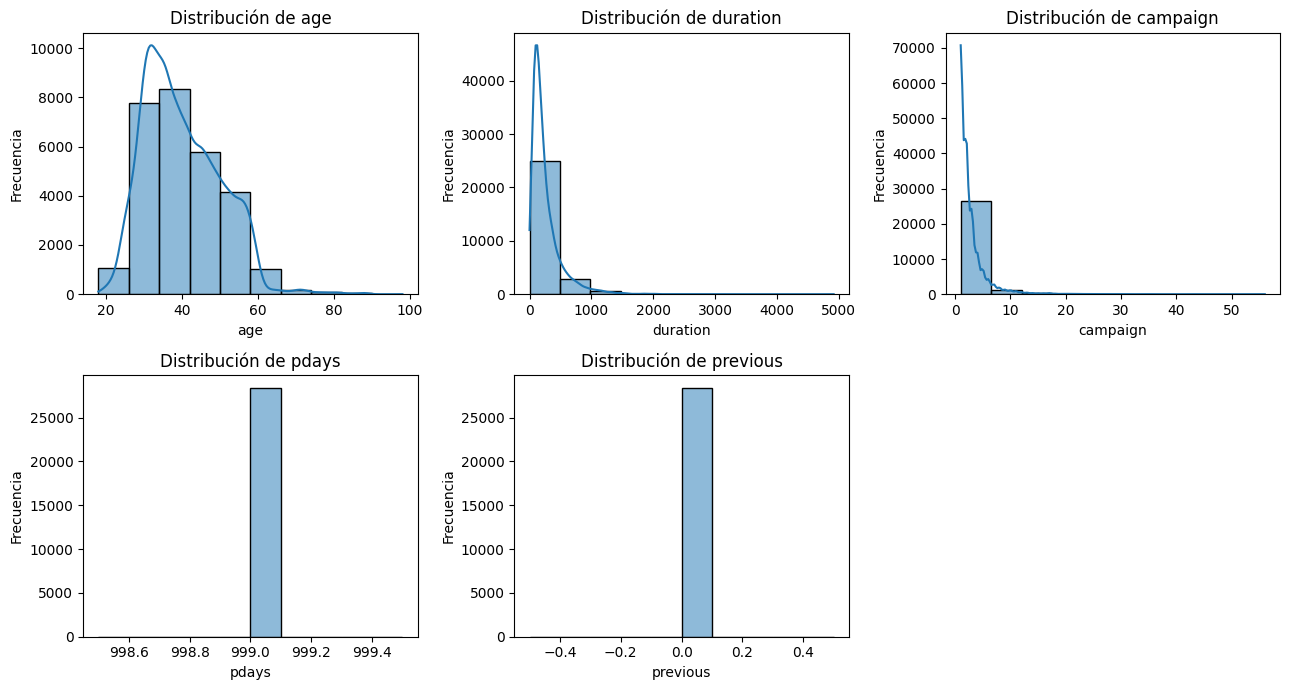

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionamos las columnas de tipo entero del DataFrame Train
numerical_columns = Train.select_dtypes(include=["int64"]).columns
plt.figure(figsize=(13, 7))

#Iteración sobre las columnas numéricas y generación de histograma para cada una
for index, column in enumerate(numerical_columns):
    plt.subplot(2, 3, index + 1)
    sns.histplot(Train[column], kde=True, bins=10, palette="bright")
    plt.title(f"Distribución de {column}")
    plt.xlabel(column)
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

<ipython-input-15-7ee5ba65c92b>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = column, data = Train, palette='bright')


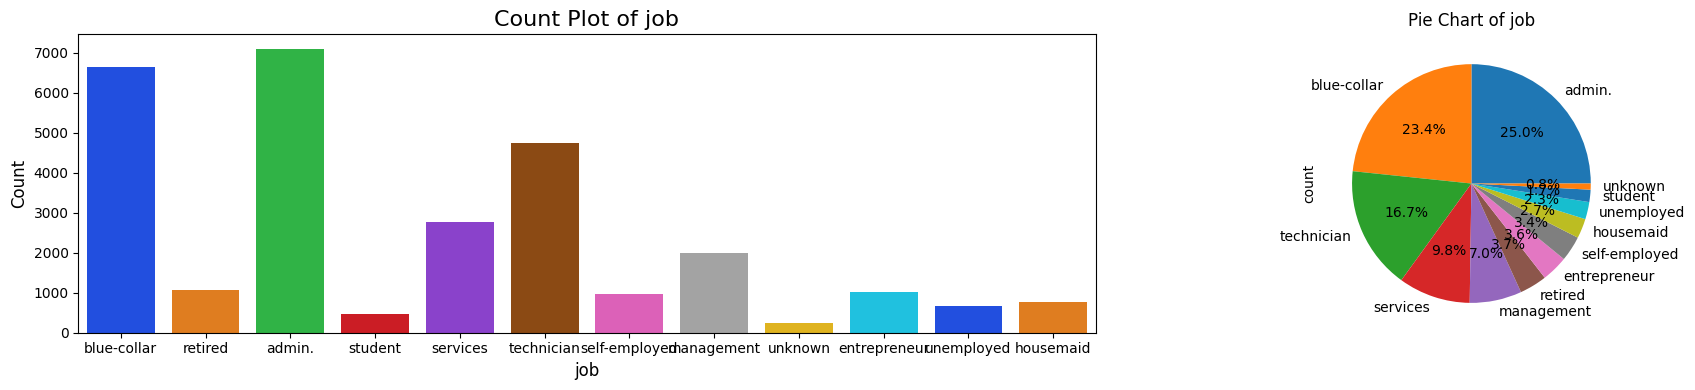

<ipython-input-15-7ee5ba65c92b>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = column, data = Train, palette='bright')


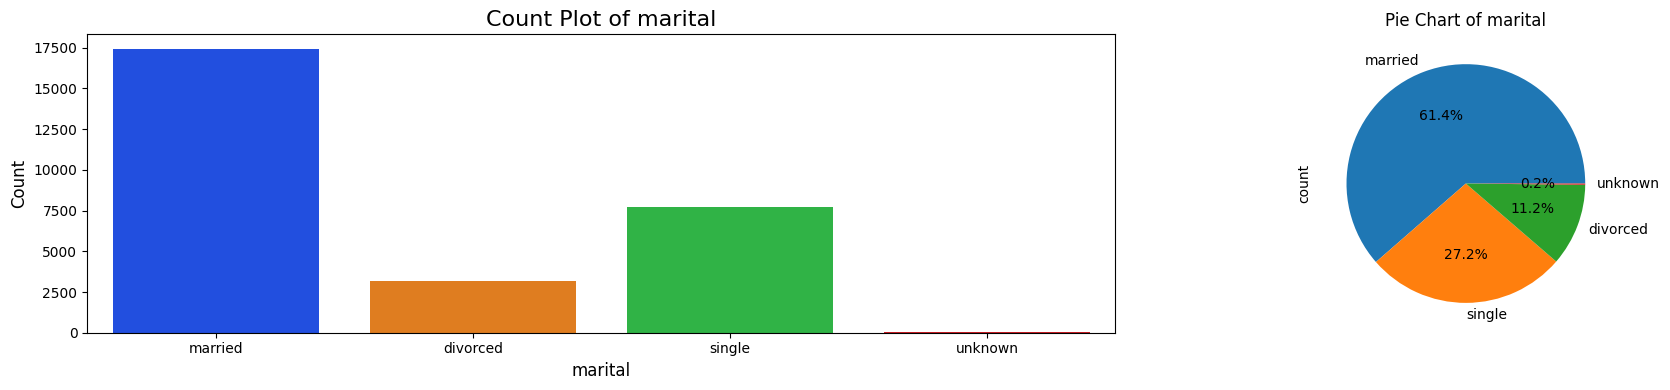

<ipython-input-15-7ee5ba65c92b>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = column, data = Train, palette='bright')


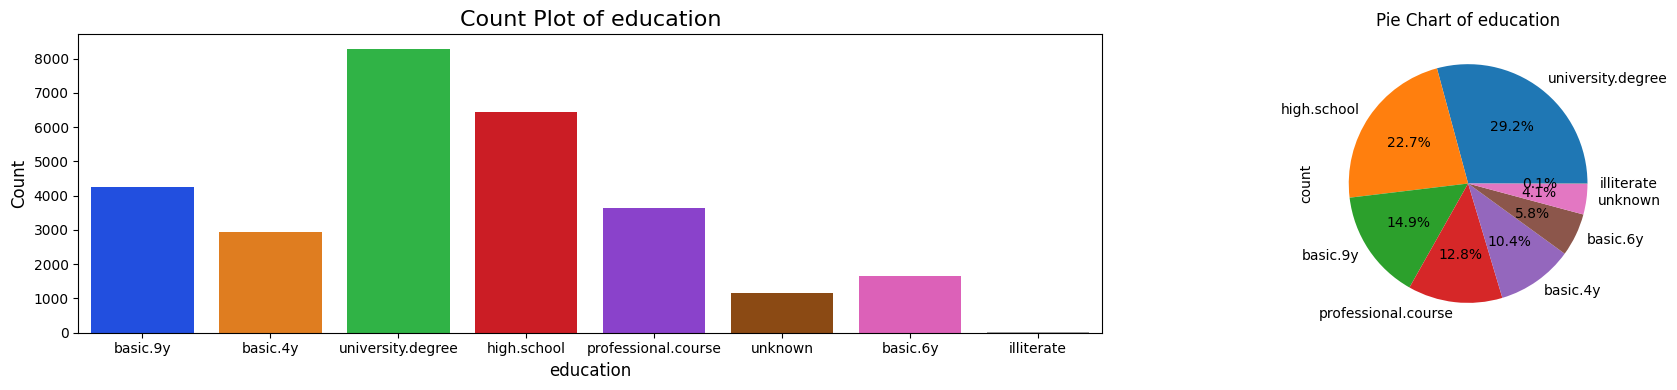

<ipython-input-15-7ee5ba65c92b>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = column, data = Train, palette='bright')


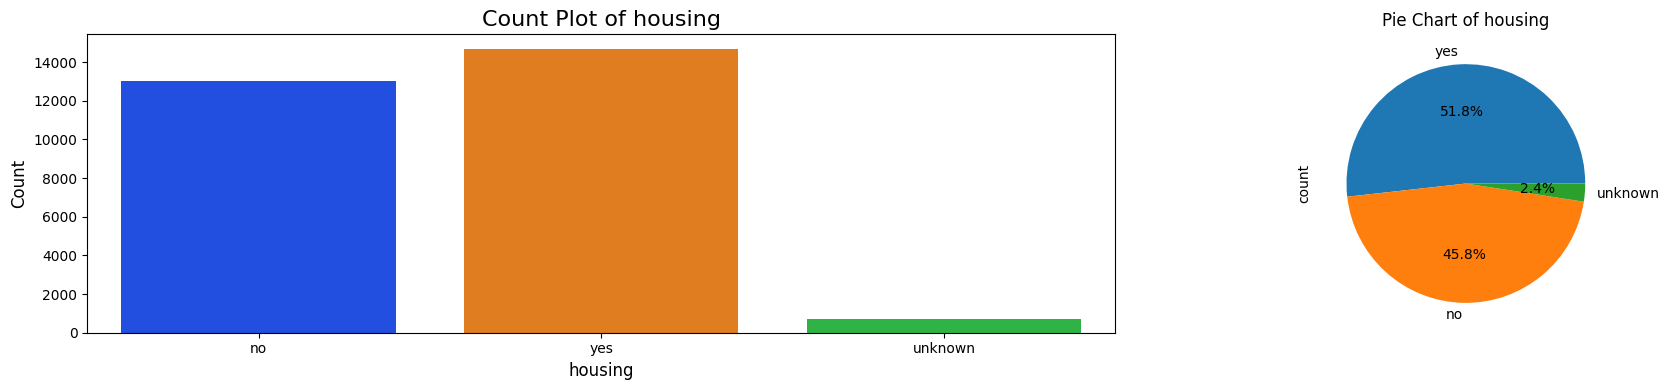

<ipython-input-15-7ee5ba65c92b>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = column, data = Train, palette='bright')


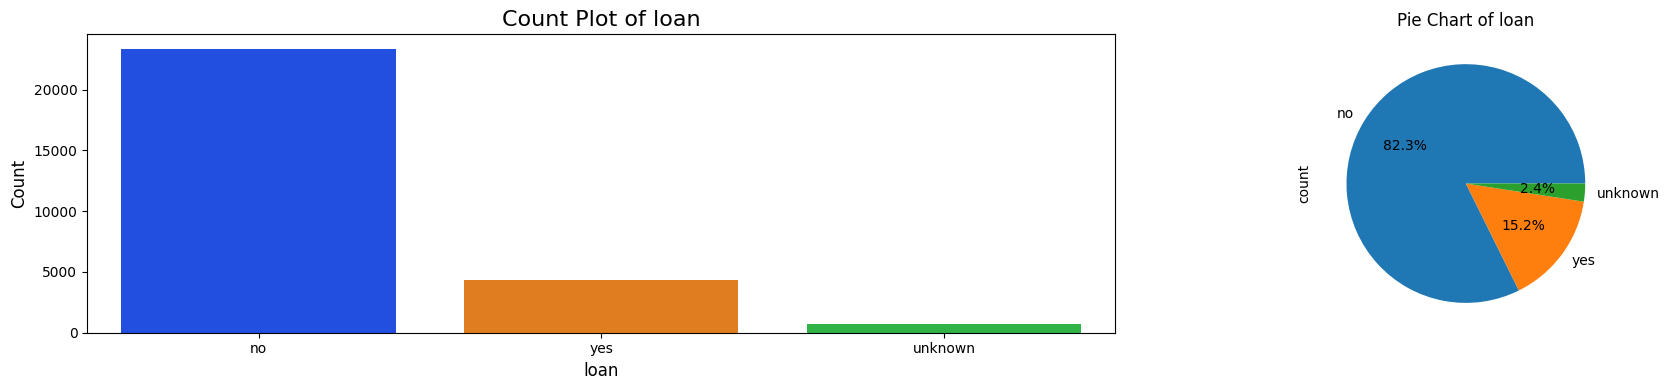

<ipython-input-15-7ee5ba65c92b>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = column, data = Train, palette='bright')


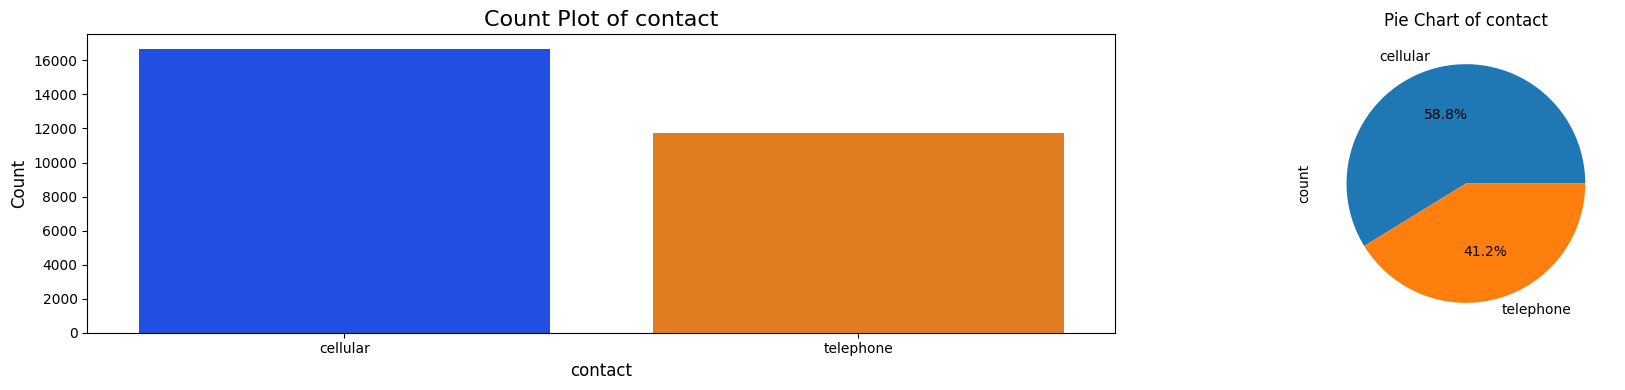

<ipython-input-15-7ee5ba65c92b>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = column, data = Train, palette='bright')


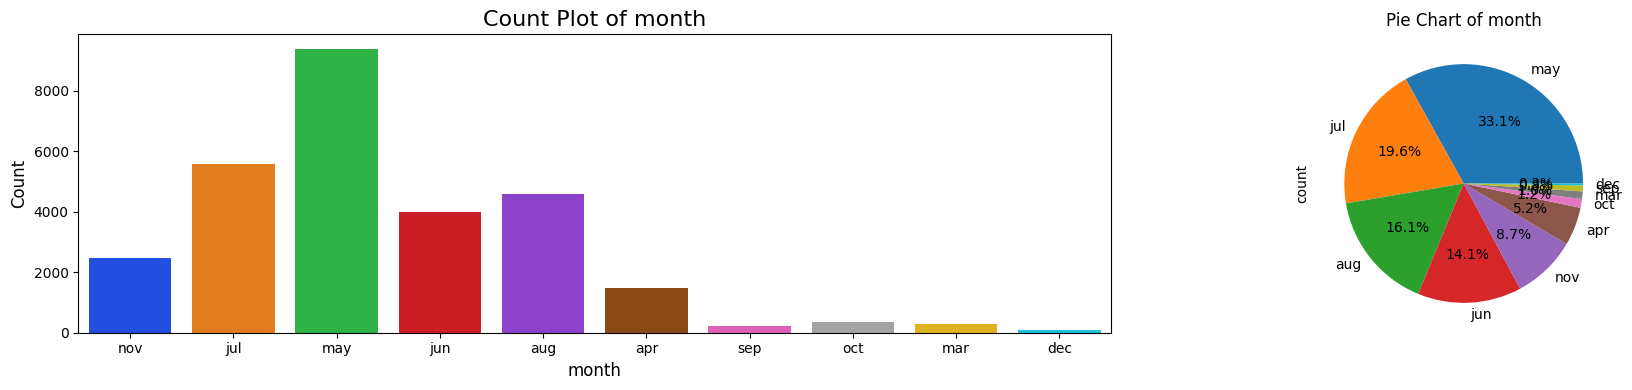

<ipython-input-15-7ee5ba65c92b>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = column, data = Train, palette='bright')


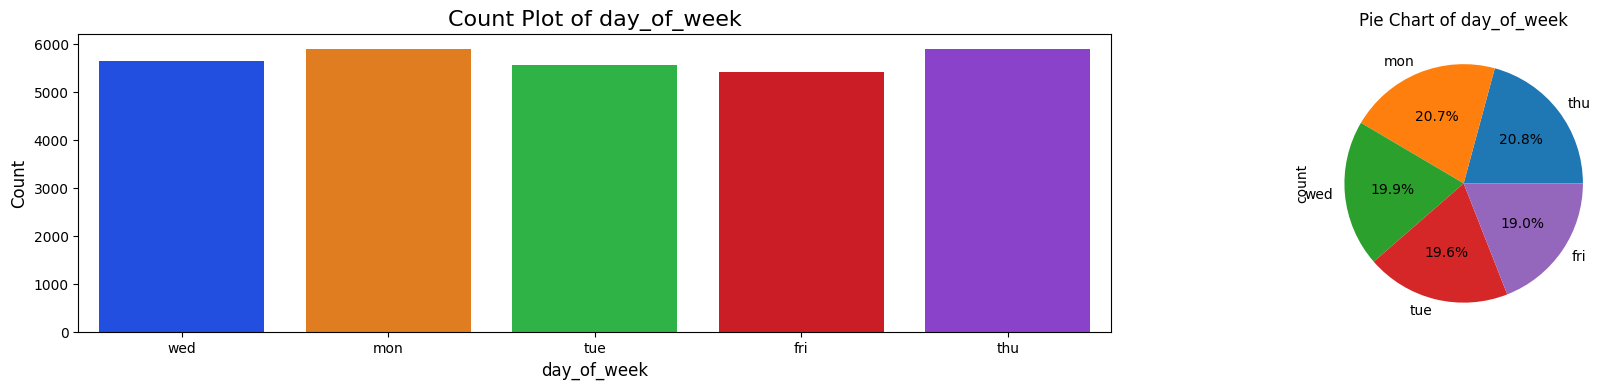

<ipython-input-15-7ee5ba65c92b>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = column, data = Train, palette='bright')


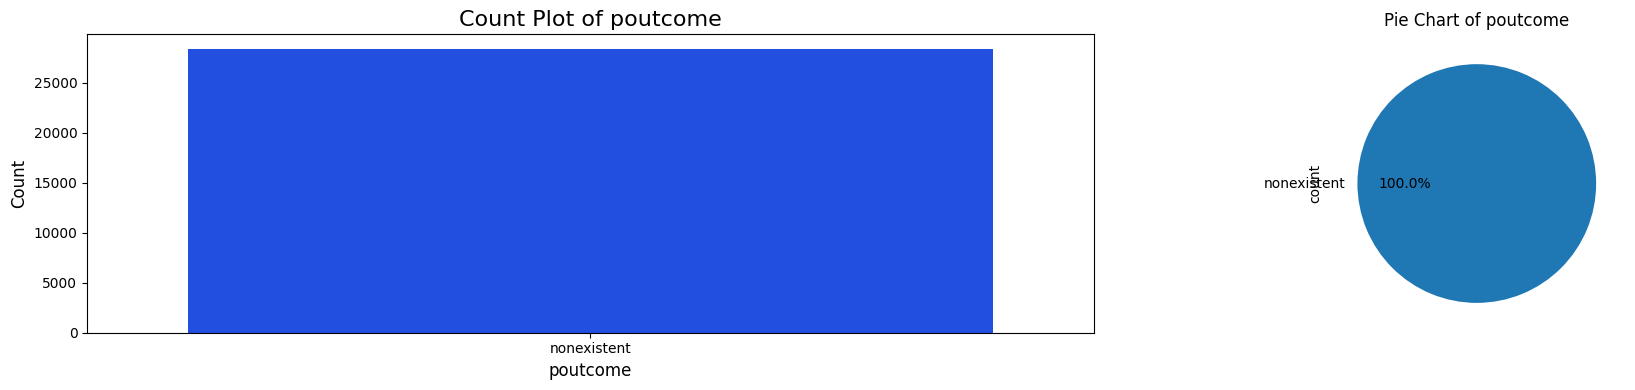

<ipython-input-15-7ee5ba65c92b>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = column, data = Train, palette='bright')


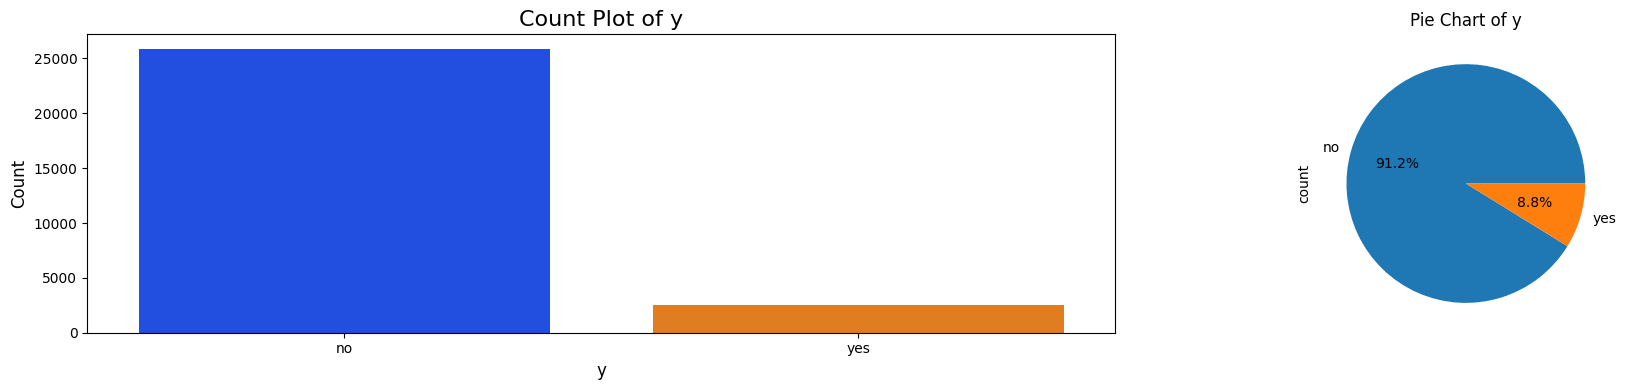

In [ ]:
cat_var = Train.select_dtypes(include=["object"]).columns
for i, column in enumerate(cat_var):
    plt.figure(figsize=(20, 4))

    plt.subplot(1,2,1)
    sns.countplot(x = column, data = Train, palette='bright')
    plt.xlabel(column, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.title(f'Count Plot of {column}', fontsize=16)

    # Pie Chart usando Matplotlib
    plt.subplot(1, 2, 2)
    Train[column].value_counts().plot(kind="pie", autopct="%1.1f%%")
    plt.title(f"Pie Chart of {column}")

    plt.tight_layout()
    plt.show()

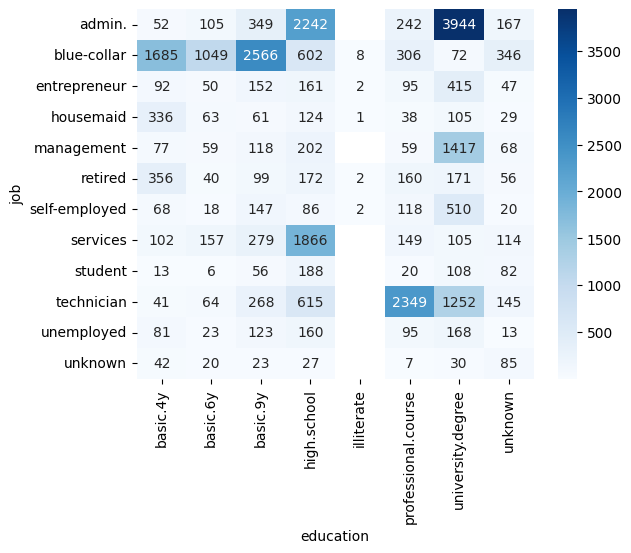

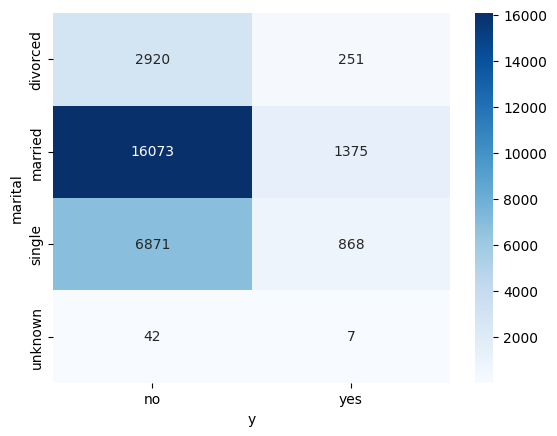

<ipython-input-3-92a233d75d95>:12: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  Train.Yes = Train[(Train['y']=='no')]


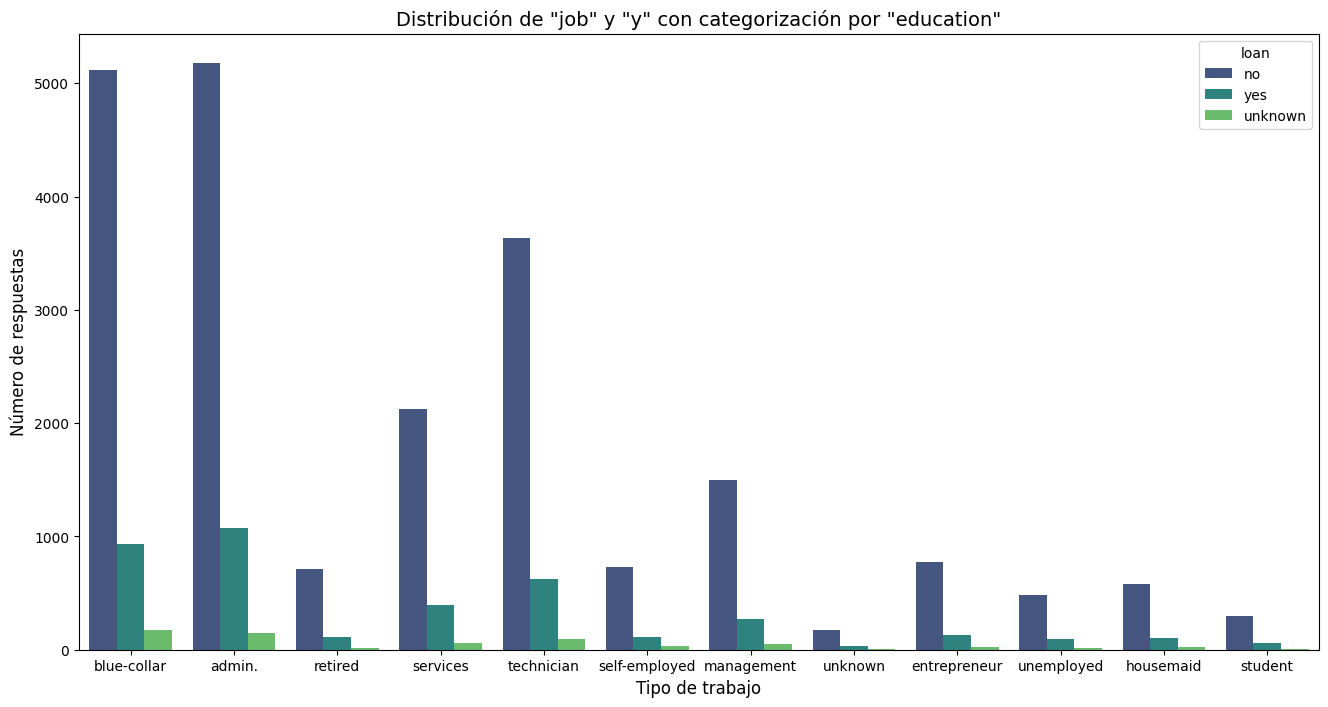

In [ ]:
#Cantidad de aceptación según anterior trabajo
cont_table1 = pd.crosstab(Train["job"],Train["education"],values=Train["y"], aggfunc='count')
sns.heatmap(cont_table1, annot=True, cmap="Blues", fmt=".0f", cbar = True)
plt.show()

##Cantidad de aceptación según anterior universidad
cont_table2 = pd.crosstab(Train["marital"], Train["y"])
sns.heatmap(cont_table2, annot=True, cmap="Blues", fmt=".0f", cbar = True)
plt.show()

# Crear gráfico de barras agrupadas
Train.Yes = Train[(Train['y']=='no')]
plt.figure(figsize=(16, 8))
sns.countplot(data=Train.Yes, x='job', hue='loan', palette='viridis', dodge=True)
plt.title('Distribución de "job" y "y" con categorización por "education"', fontsize=14)
plt.xlabel('Tipo de trabajo', fontsize=12)
plt.ylabel('Número de respuestas', fontsize=12)
plt.show()

In [ ]:
#Importando librerias scikit-learn que permitiran transformar la data y poder elaborar una predicción con distintos modelos para poder optar por el más preciso.

#Modelos de predicción
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

#Recursos de transformación de datos y pruebas
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, mean_squared_error, precision_score, recall_score

In [ ]:
#Se arma una tupla con la lista de modelos para una posterior iteración en la generación de predicciones
classificaction_models = {
    'RandomForest': RandomForestClassifier(),
    'GradientBoosting': GradientBoostingClassifier(),
    'LogisticRegression': LogisticRegression(),
    'SVC': SVC(),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier()
}

In [ ]:
#Establecer datos de entrada (a) y el dato objetivo (b) (En este caso sería la columna de nombre 'y')

a = Train.drop(columns=['y'])
b = Train[('y')]


numeric_var       = a.select_dtypes(include=['int64','float']).columns
categoric_var     = a.select_dtypes(include='object').columns

In [ ]:
numeric_transformer = Pipeline([('Scaler', StandardScaler())])
categoric_transformer = Pipeline([('OneHot', OneHotEncoder())])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_var),
        ('cat', categoric_transformer, categoric_var)
    ]
)

Best_acc = 0
Best_mod = None

for model_name, model in classificaction_models.items():
  pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])

  a_Train, a_Test, b_Train, b_Test = train_test_split(a,b, test_size = 0.2, random_state = 50)

  pipe.fit(a_Train, b_Train)
  y_pred = pipe.predict(a_Test)

  acc = accuracy_score(b_Test, y_pred)

  if acc > Best_acc:
    Best_acc = acc
    Best_mod = model

  print(f'Modelo: {model_name}, Accuracy: {acc}')

print("\nBest Model:", Best_mod)
print("Best Model Accuracy:", Best_acc)

Modelo: RandomForest, Accuracy: 0.9174586413234777
Modelo: GradientBoosting, Accuracy: 0.9195705737416403
Modelo: LogisticRegression, Accuracy: 0.9171066525871172
Modelo: SVC, Accuracy: 0.9142907426962337
Modelo: KNN, Accuracy: 0.9139387539598732
Modelo: Decision Tree, Accuracy: 0.8901795142555439

Best Model: GradientBoostingClassifier()
Best Model Accuracy: 0.9195705737416403


In [ ]:
# Realizar las predicciones
y_pred = pipe.predict(a_Test)

# Obtener las probabilidades de predicción
y_prob = pipe.predict_proba(a_Test)

# Tomando como umbral de decisión el 50% (si probabilidad de asumir > 0.5, asumirá)
clientes_predichos_que_asumiran = (y_prob[:, 1] > 0.60).sum()

# Número de clientes que el modelo predice que NO asumirán el depósito
clientes_predichos_que_no_asumiran = len(y_prob) - clientes_predichos_que_asumiran

# Predicciones binarias del modelo
clientes_predichos_que_asumiran_binario = (y_pred == 'yes').sum()
clientes_predichos_que_no_asumiran_binario = (y_pred == "no").sum()

# Predicciones con probabilidades (umbral 60%)
clientes_predichos_que_asumiran_probabilidad = (y_prob[:, 1] > 0.60).sum()
clientes_predichos_que_no_asumiran_probabilidad = len(y_prob) - clientes_predichos_que_asumiran_probabilidad

#Clientes actuales de la tabla que aceptaron depósito de largo plazo
clientes_depósito_train = Train[(Train['y'] == 'yes')]['y'].count()
clientes_no_depósito_train = Train[(Train['y'] == 'no')]['y'].count()
#Resumen
print("### Resumen de Resultados ###")
print(f"Clientes predichos que asumirán el depósito (predicción binaria): {clientes_predichos_que_asumiran_binario}")
print(f"Clientes predichos que NO asumirán el depósito (predicción binaria): {clientes_predichos_que_no_asumiran_binario}")
print()
print(f"Clientes predichos que asumirán el depósito (probabilidad > 0.60): {clientes_predichos_que_asumiran_probabilidad}")
print(f"Clientes predichos que NO asumirán el depósito (probabilidad <= 0.60): {clientes_predichos_que_no_asumiran_probabilidad}")
print()
print(f'Clientes que aceptaron el depósito previamente según el dataset: {clientes_depósito_train}')
print(f'Clientes que aceptaron el depósito previamente según el dataset: {clientes_no_depósito_train}')

### Resumen de Resultados ###
Clientes predichos que asumirán el depósito (predicción binaria): 529
Clientes predichos que NO asumirán el depósito (predicción binaria): 5153

Clientes predichos que asumirán el depósito (probabilidad > 0.60): 529
Clientes predichos que NO asumirán el depósito (probabilidad <= 0.60): 5153

Clientes que aceptaron el depósito previamente según el dataset: 2501
Clientes que aceptaron el depósito previamente según el dataset: 25906
28407


              Feature  Importance
1            duration    0.653971
0                 age    0.078721
42          month_mar    0.051097
41          month_jun    0.038313
45          month_oct    0.030883
37          month_apr    0.024693
36  contact_telephone    0.022973
35   contact_cellular    0.020927
46          month_sep    0.020143
39          month_dec    0.010797


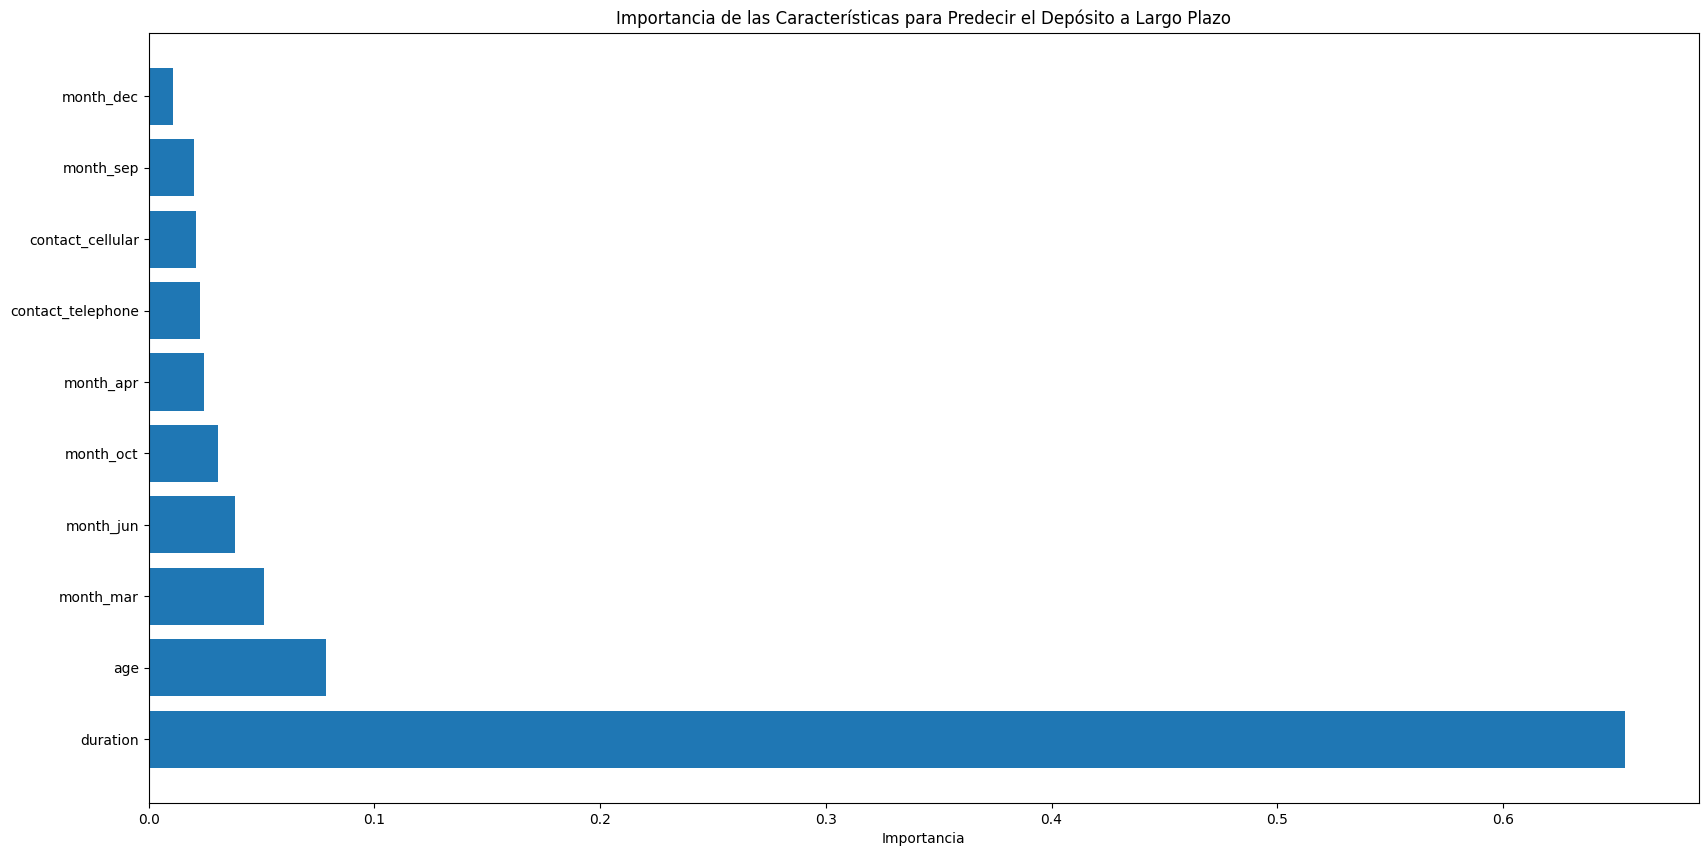

In [ ]:
# Obtener la importancia de las características
feature_importances = Best_mod.feature_importances_

feature_names = numeric_var.tolist() + preprocessor.named_transformers_['cat']['OneHot'].get_feature_names_out(categoric_var.tolist()).tolist()


# Combinarla con los nombres de las características
import pandas as pd
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})


# Ordenar por importancia
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)


# Mostrar las características más importantes
print(importance_df)



import matplotlib.pyplot as plt

# Crear gráfico de barras de las importancias
plt.figure(figsize=(20, 10))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importancia')
plt.title('Importancia de las Características para Predecir el Depósito a Largo Plazo')
plt.show()
